In [1]:
!pip install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use('default')

In [2]:
PATH = "../Datasets/UCI Dynamic Gas Mixtures"

In [3]:
ethylene_co = pd.read_csv(PATH + "/ethylene_CO.txt", sep=r'\s+', skiprows=1, names=['Time', 'Methane', 'Ethylene'] + [f's{i}' for i in range(1, 17)])

In [4]:
ethylene_co

,Time,Methane,Ethylene,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16
0,0.00,0.0,0.0,-50.85,-1.95,-41.82,1.30,-4.07,-28.73,-13.49,-3.25,55139.95,50669.50,9626.26,9762.62,24544.02,21420.68,7650.61,6928.42
1,0.01,0.0,0.0,-49.40,-5.53,-42.78,0.49,3.58,-34.55,-9.59,5.37,54395.77,50046.91,9433.20,9591.21,24137.13,20930.33,7498.79,6800.66
2,0.01,0.0,0.0,-40.04,-16.09,-27.59,0.00,-7.16,-42.14,-12.52,-5.86,53960.02,49299.30,9324.40,9449.81,23628.90,20504.94,7369.67,6697.47
3,0.03,0.0,0.0,-47.14,-10.57,-32.28,4.40,-11.22,-37.94,-7.16,-1.14,53047.71,48907.00,9170.64,9305.58,23101.66,20101.42,7285.13,6578.52
4,0.04,0.0,0.0,-33.58,-20.79,-33.25,6.03,3.42,-34.22,-14.46,8.31,52700.28,48330.96,9073.64,9163.47,22689.54,19694.07,7156.74,6468.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4208256,42087.51,0.0,0.0,1127.81,105.93,2117.39,2247.58,1207.59,1646.73,2089.97,2262.98,1061.70,1070.47,2570.33,2073.57,709.06,775.36,2513.75,1848.65
4208257,42087.52,0.0,0.0,1140.73,96.46,2105.93,2253.69,1216.39,1624.47,2073.57,2246.61,1063.89,1075.26,2580.88,2083.78,698.24,768.93,2511.20,1843.63
4208258,42087.53,0.0,0.0,1123.99,107.92,2111.18,2245.63,1215.36,1628.44,2085.45,2271.80,1059.31,1063.49,2583.20,2090.20,709.62,775.73,2510.18,1841.80
4208259,42087.54,0.0,0.0,1131.44,111.08,2114.76,2249.54,1197.99,1612.17,2078.32,2272.29,1063.69,1066.08,2578.56,2100.92,716.72,779.14,2508.91,1851.17


In [ ]:
# запустить это если без нормализации
normalized = False

In [5]:
# апустить это, если с нормализацией
normalize_columns = ['Methane', 'Ethylene'] + [f's{i}' for i in range(1, 17)]
def min_max_scaler(normalize_columns, ds):
    for col in normalize_columns:
        ds[col] = (ds[col] - ds[col].min()) / (ds[col].max() - ds[col].min())
min_max_scaler(normalize_columns, ethylene_co)
normalized = True

In [6]:
def mono_exp(x, m, t, b):
    return m * np.exp(-t * x) + b

In [7]:
from_index = 52000
to_index = 53800

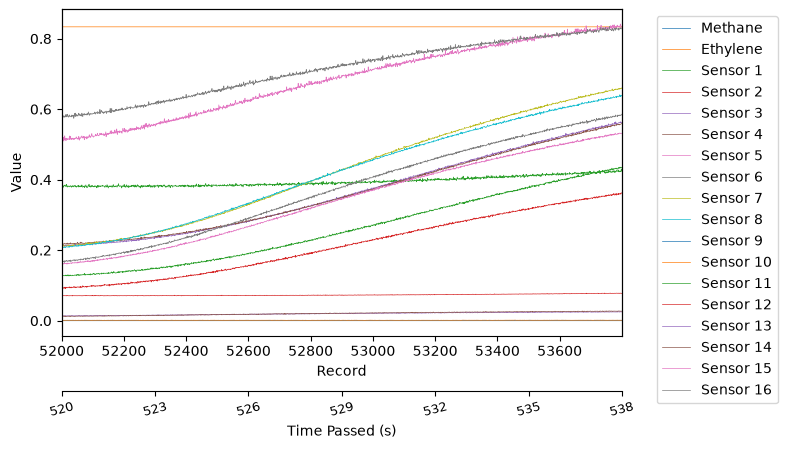

In [8]:
x = ethylene_co.index.to_list()
label = "Record"

line_width = 0.5
plt.plot(x[from_index : to_index], ethylene_co['Methane'].iloc[from_index : to_index], label="Methane", linewidth=line_width)
plt.plot(x[from_index : to_index], ethylene_co['Ethylene'].iloc[from_index : to_index], label="Ethylene", linewidth=line_width)
for i in range(1, 17):
    plt.plot(x[from_index : to_index], ethylene_co[f's{i}'].iloc[from_index : to_index], label=f"Sensor {i}", linewidth=line_width)
plt.margins(x=0)
plt.xlabel(label)
plt.ylabel("Value")
plt.title("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

# НАЧАЛО БЛОКА: В этом блоке код написан нейросетью для отображения оси времени
ax1 = plt.gca()
ax2 = ax1.twiny()

ax2.spines['bottom'].set_position(('outward', 40))
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')

x_slice = x[from_index : to_index]
time_slice = ethylene_co['Time'].iloc[from_index : to_index].to_list()

n_ticks = 6
step = max(1, len(time_slice) // n_ticks)
tick_indices = list(range(0, len(time_slice), step))
if (len(time_slice) - 1) not in tick_indices:
    tick_indices.append(len(time_slice) - 1)

tick_x_values = [x_slice[i] for i in tick_indices]
tick_labels = [int(time_slice[i]) for i in tick_indices]

ax2.set_xticks(tick_x_values)
ax2.set_xticklabels(tick_labels, rotation=15, fontsize=9)
ax2.set_xlabel("Time Passed (s)")

ax2.set_xlim(ax1.get_xlim())
# КОНЕЦ БЛОКА

plt.subplots_adjust(right=1, bottom=0.2)
plt.show()

In [9]:
xs = ethylene_co.index.to_list()[from_index:to_index]
xs = np.array(xs)

R² = 0.9773367419747935
t = -0.0011571480228543245


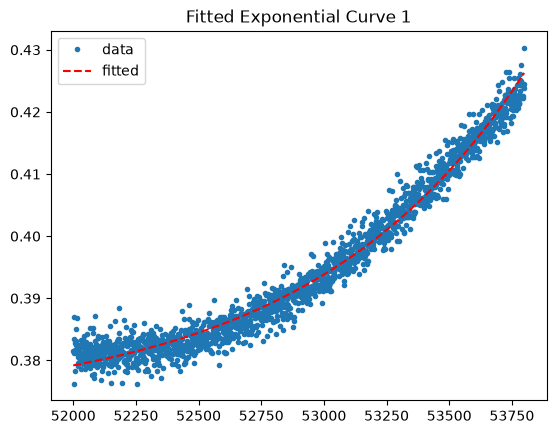

R² = 0.9831477021710712
t = -0.001196457360278642


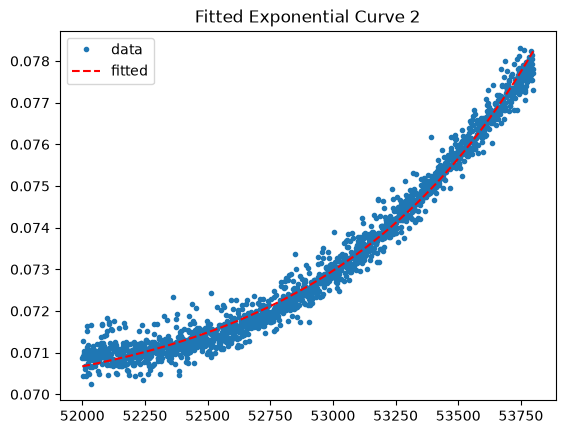

R² = 0.9952341794737893
t = -0.00040683533199523917


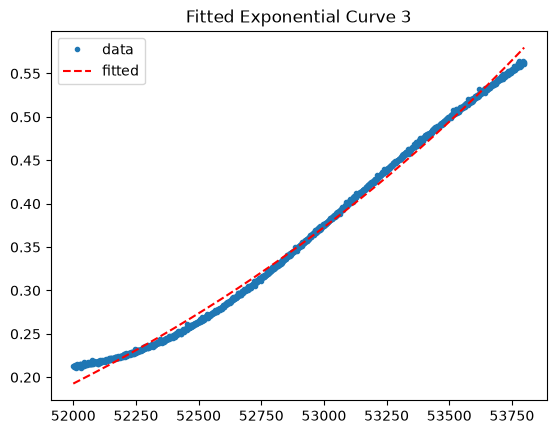

R² = 0.9951114341265394
t = -0.00043861492663566543


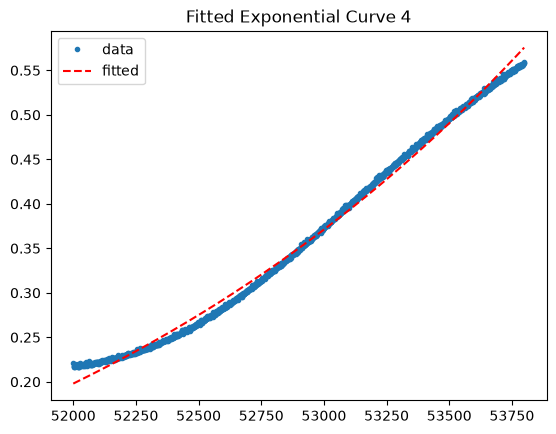

R² = 0.9927230970323374
t = -5.9218781241467814e-08


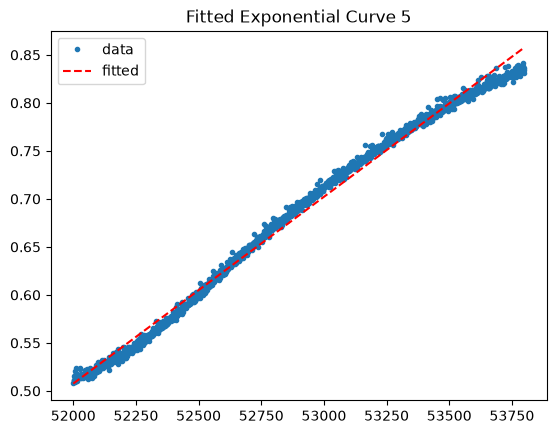

R² = 0.9892686483822601
t = -5.964076514333843e-08


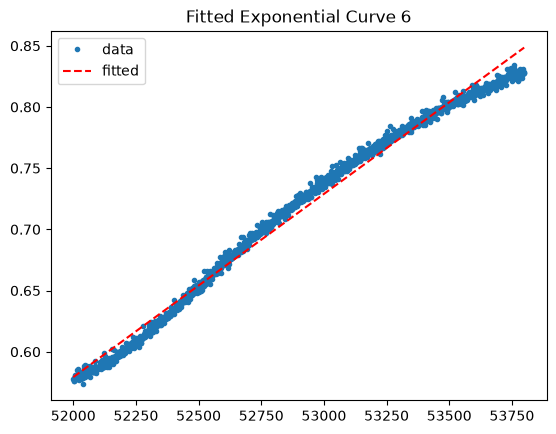

R² = 0.9943495474234127
t = -4.1422501236816536e-05


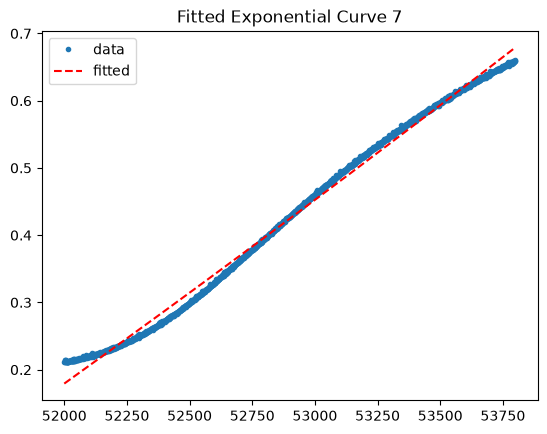

R² = 0.9951018989966574
t = -1.1788197610801559e-07


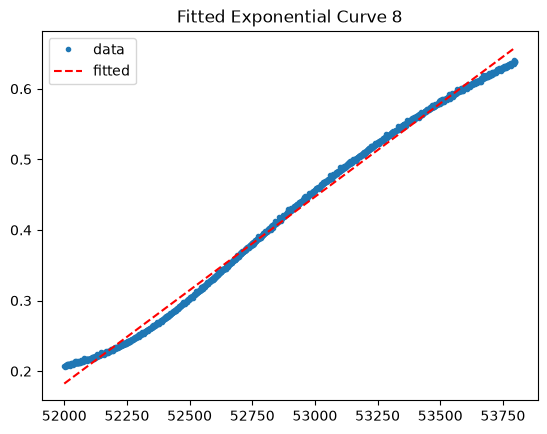

R² = 0.017380896006245483
t = 2.434948352996551e-07


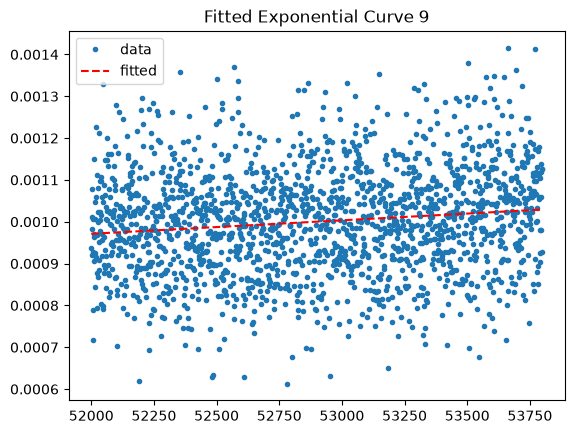

R² = 0.12244700371658646
t = -0.001733248710307652


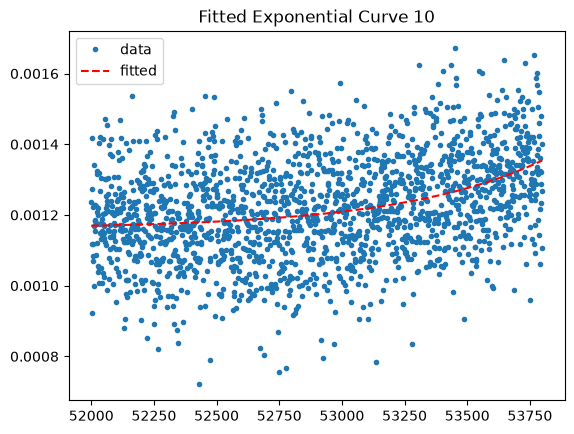

R² = 0.9958072359947867
t = -0.00039242852813405


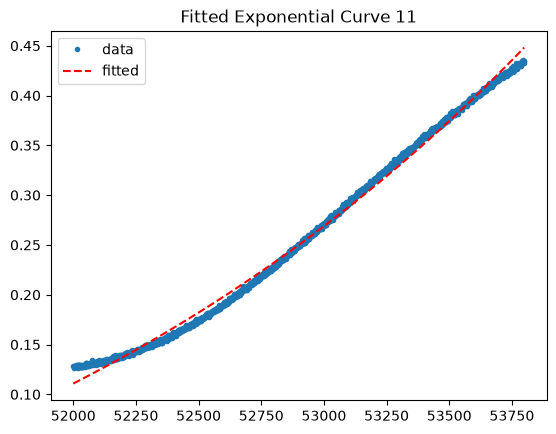

R² = 0.9955923286503643
t = -0.00022780278504074436


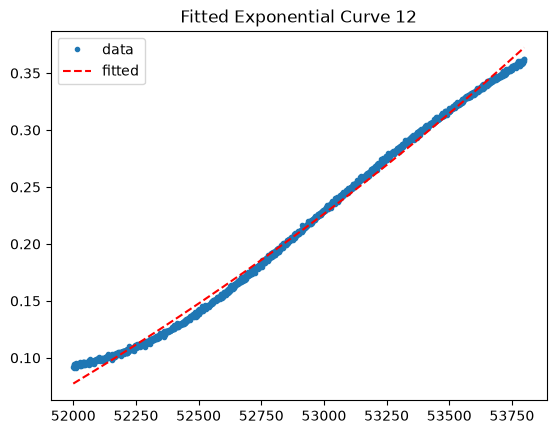

R² = 0.9771100310576383
t = -5.127186078810415e-08


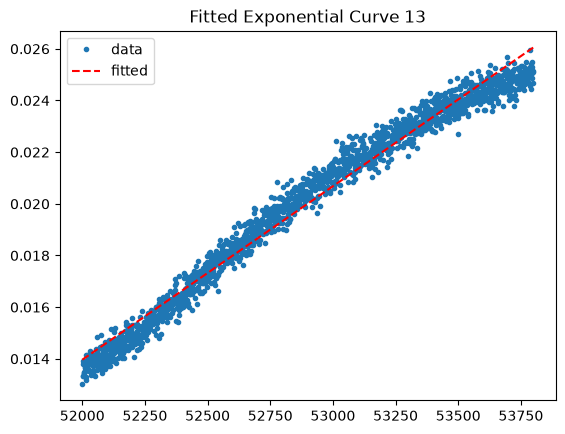

R² = 0.9810663652407118
t = -5.185398329075623e-08


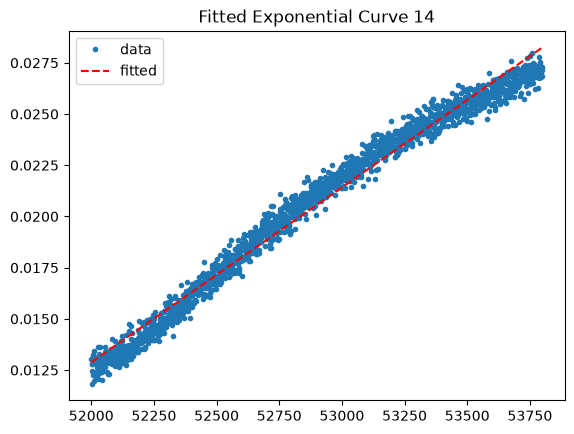

R² = 0.9959755989428484
t = -2.705543572041577e-07


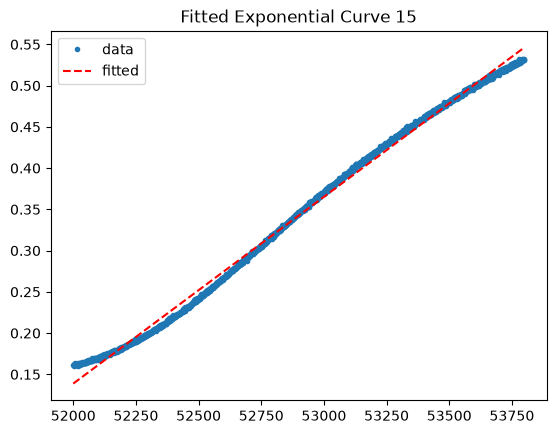

R² = 0.9958332049367258
t = -1.2139245953075032e-07


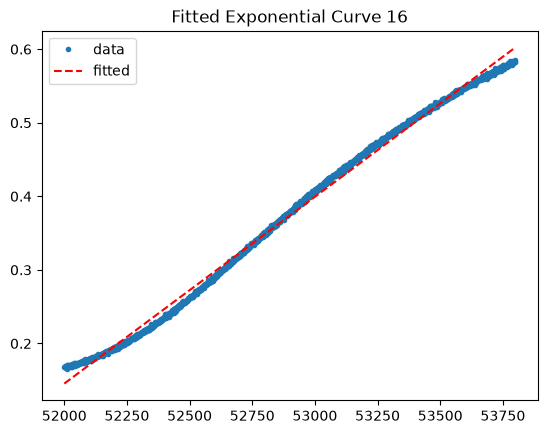

In [10]:
fitting_results = []

for i in range(3, 19):
    ys = ethylene_co.iloc[from_index:to_index, i]
    ys = np.array(ys)

    xs_shifted = xs - xs[0]

    # 2. Автоматически вычисляем ИДЕАЛЬНУЮ подсказку (p0) под любые ваши данные
    start_y = ys[0]                     # Начало (на графике ~1320)
    end_y = ys[-1]                      # Конец (на графике ~1520)
    amplitude = end_y - start_y         # На сколько выросла кривая (~200)

    # Подсказка для скорости: берем очень маленькое число, так как точек много (2000)
    # Знак минус обязателен, чтобы кривая РАСЛА вверх, как на графике
    estimated_t = -0.001

    p0 = (amplitude, estimated_t, start_y)

    # 3. Запускаем поиск (передаем сдвинутый xs_shifted)
    params, cv = scipy.optimize.curve_fit(mono_exp, xs_shifted, ys, p0=p0, maxfev=20000)
    m, t, b = params

    # 4. Считаем качество и строим график (используем xs_shifted!)
    fitted_ys = mono_exp(xs_shifted, m, t, b)

    squaredDiffs = np.square(ys - fitted_ys)
    squaredDiffsFromMean = np.square(ys - np.mean(ys))
    rSquared = 1 - np.sum(squaredDiffs) / np.sum(squaredDiffsFromMean)
    print(f"R² = {rSquared}")
    print(f"t = {t}")

    fitting_results.append({
        "sensor_number": i - 2,
        "m": m,
        "t": t,
        "b": b,
        "r2": rSquared
    })

    # Рисуем оригинальный xs (чтобы шкала на графике осталась красивой)
    plt.plot(xs, ys, '.', label="data")
    plt.plot(xs, fitted_ys, '--', label="fitted", color="red")
    plt.title(f"Fitted Exponential Curve {i-2}")
    plt.legend()
    plt.savefig(f"exponential_fitting_graphs/{"normalized/" if normalized else ""}exponential_fitting_graph_sensor{i-2}.png", dpi=300)
    plt.show()

df_results = pd.DataFrame(fitting_results)
df_results.to_csv(f"fitting_parameters_results{"_normalized" if normalized else ""}.csv", index=False)

In [11]:
from_index = 62000
to_index = 68000

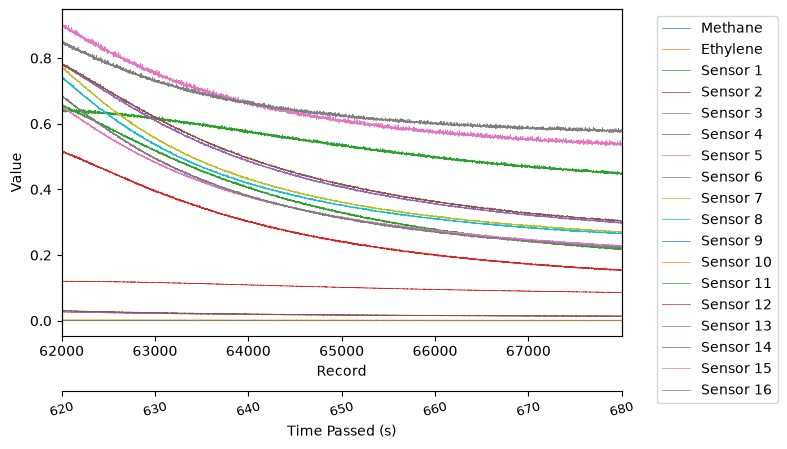

In [12]:
x = ethylene_co.index.to_list()
label = "Record"

line_width = 0.5
plt.plot(x[from_index : to_index], ethylene_co['Methane'].iloc[from_index : to_index], label="Methane", linewidth=line_width)
plt.plot(x[from_index : to_index], ethylene_co['Ethylene'].iloc[from_index : to_index], label="Ethylene", linewidth=line_width)
for i in range(1, 17):
    plt.plot(x[from_index : to_index], ethylene_co[f's{i}'].iloc[from_index : to_index], label=f"Sensor {i}", linewidth=line_width)
plt.margins(x=0)
plt.xlabel(label)
plt.ylabel("Value")
plt.title("")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

# НАЧАЛО БЛОКА: В этом блоке код написан нейросетью для отображения оси времени
ax1 = plt.gca()
ax2 = ax1.twiny()

ax2.spines['bottom'].set_position(('outward', 40))
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')

x_slice = x[from_index : to_index]
time_slice = ethylene_co['Time'].iloc[from_index : to_index].to_list()

n_ticks = 6
step = max(1, len(time_slice) // n_ticks)
tick_indices = list(range(0, len(time_slice), step))
if (len(time_slice) - 1) not in tick_indices:
    tick_indices.append(len(time_slice) - 1)

tick_x_values = [x_slice[i] for i in tick_indices]
tick_labels = [int(time_slice[i]) for i in tick_indices]

ax2.set_xticks(tick_x_values)
ax2.set_xticklabels(tick_labels, rotation=15, fontsize=9)
ax2.set_xlabel("Time Passed (s)")

ax2.set_xlim(ax1.get_xlim())
# КОНЕЦ БЛОКА

plt.subplots_adjust(right=1, bottom=0.2)
plt.show()

In [13]:
xs = ethylene_co.index.to_list()[from_index:to_index]
xs = np.array(xs)

R² = 0.9947097915651961
t = 7.60740496853134e-05


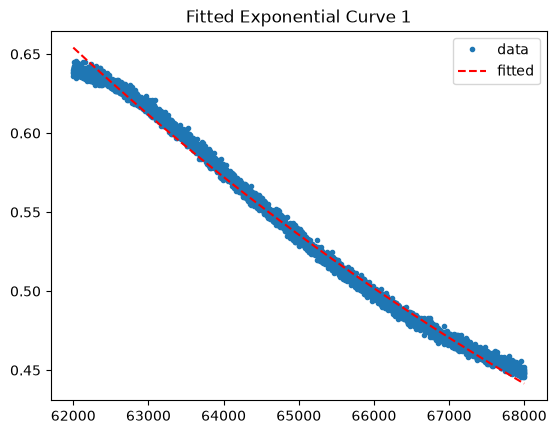

R² = 0.9945198406398951
t = 6.285980159509965e-05


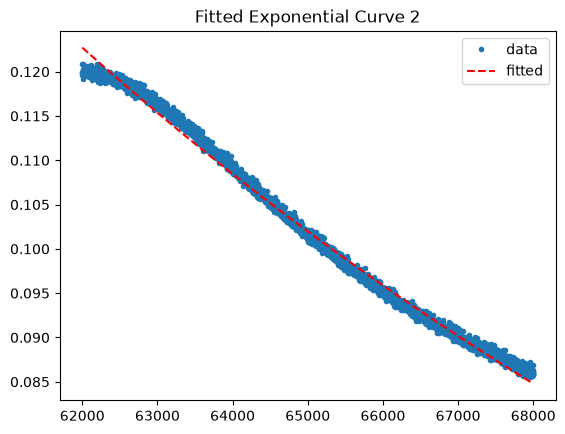

R² = 0.999770554902999
t = 0.0004195068985512717


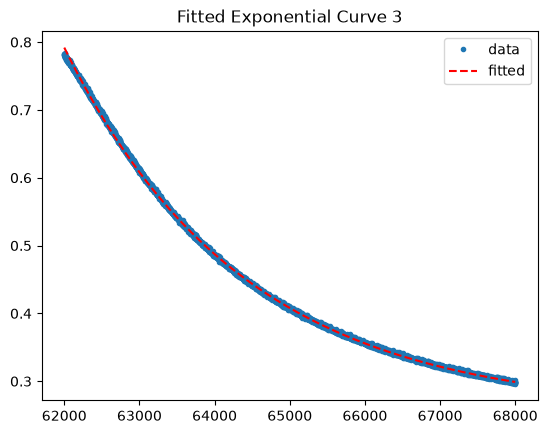

R² = 0.9996735131844338
t = 0.00040343388526383237


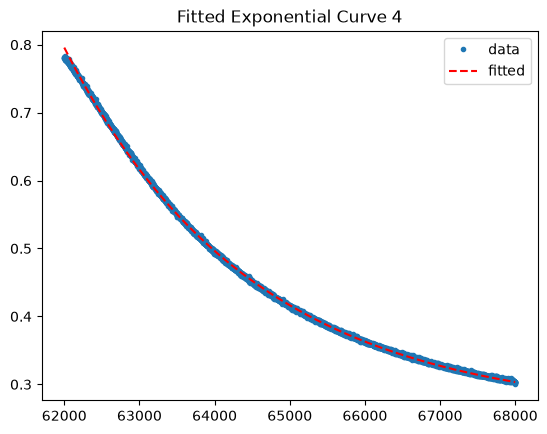

R² = 0.9991128337572011
t = 0.0004881712410775049


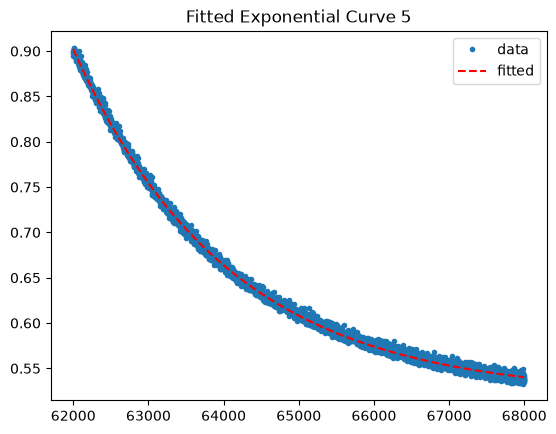

R² = 0.9989169609601546
t = 0.0005437116219009363


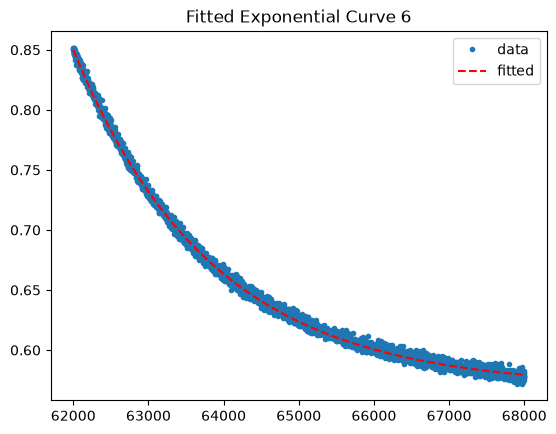

R² = 0.9997324552783109
t = 0.0005308245141400437


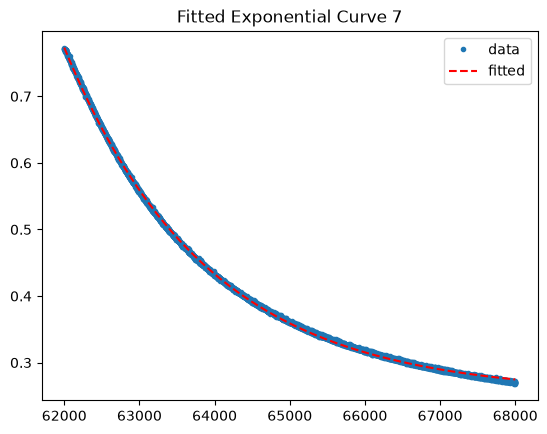

R² = 0.9996941479426118
t = 0.0005303934703294724


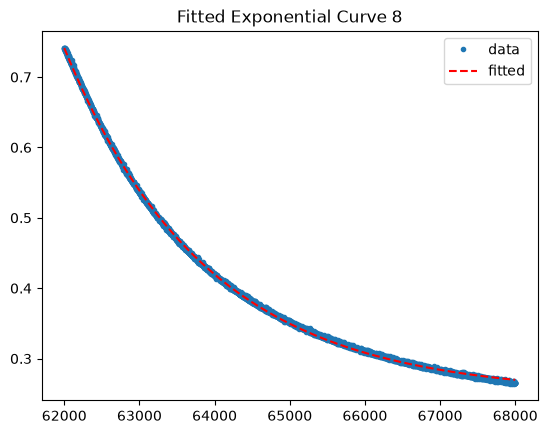

R² = 0.5203822860620182
t = 0.00020171211910976027


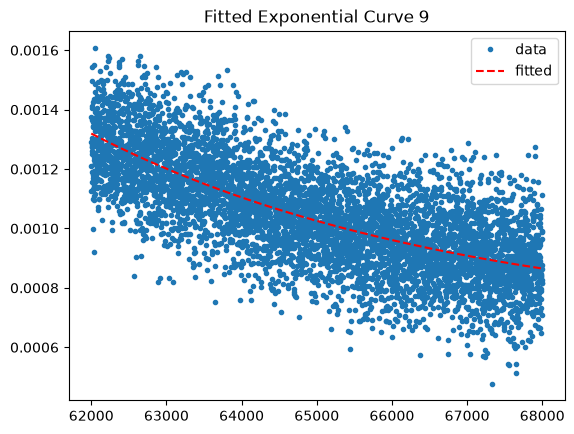

R² = 0.8537018209821157
t = 5.146653821825457e-05


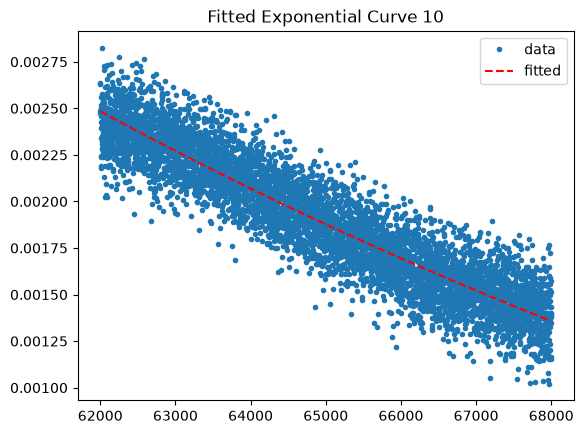

R² = 0.9995313400509751
t = 0.0003611547018427264


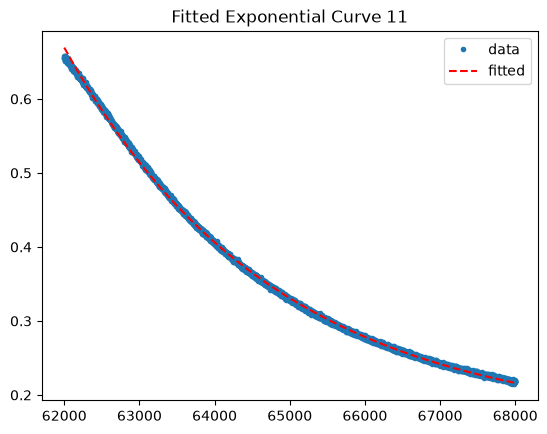

R² = 0.9996195924641164
t = 0.00038748435517594026


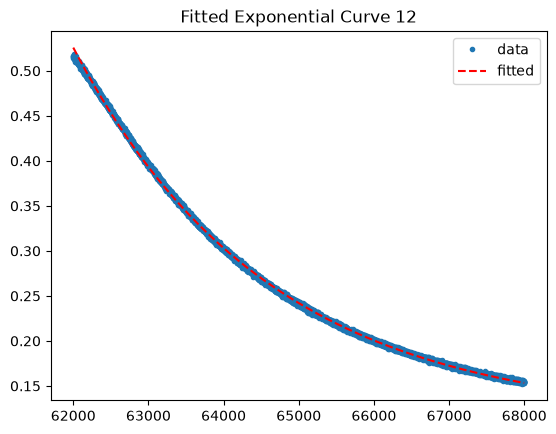

R² = 0.9899675149133979
t = 0.00040200584765261047


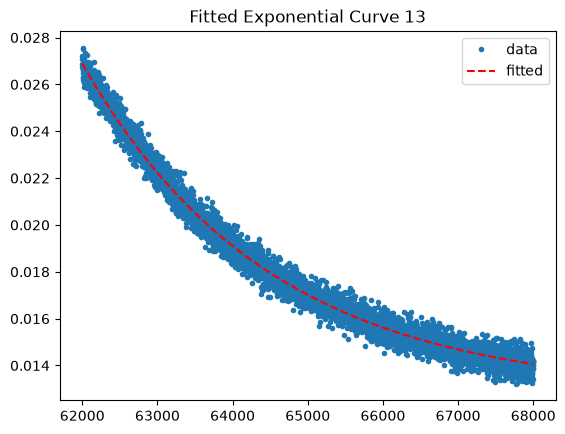

R² = 0.9923488877536419
t = 0.0004070898565686778


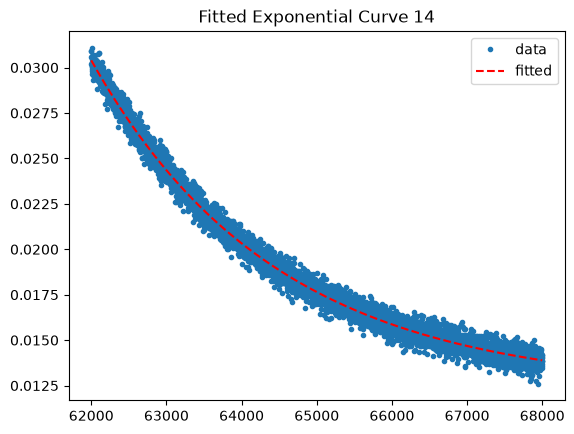

R² = 0.9997325605806977
t = 0.00047377840343094377


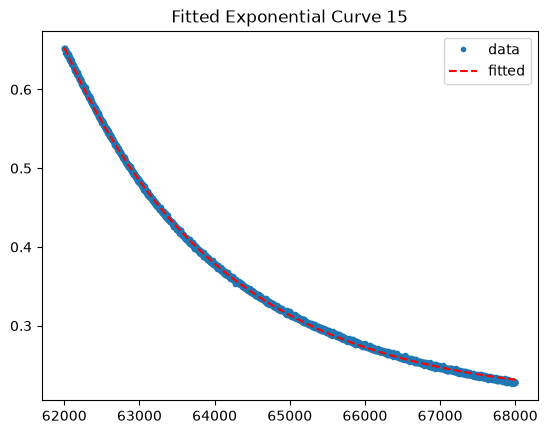

R² = 0.999718773525262
t = 0.0004957400832871265


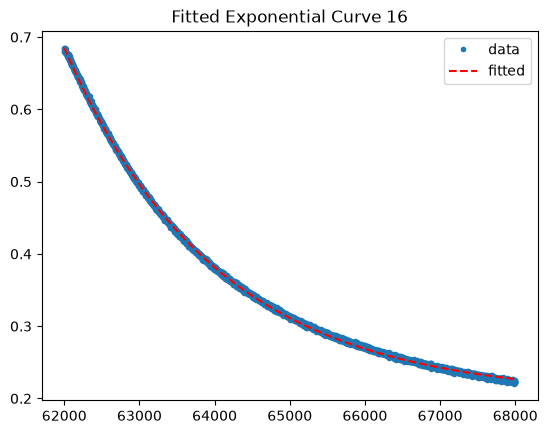

In [14]:
fitting_results = []

for i in range(3, 19):
    ys = ethylene_co.iloc[from_index:to_index, i]
    ys = np.array(ys)

    xs_shifted = xs - xs[0]

    # 2. Автоматически вычисляем ИДЕАЛЬНУЮ подсказку (p0) под любые ваши данные
    start_y = ys[0]                     # Начало (на графике ~1320)
    end_y = ys[-1]                      # Конец (на графике ~1520)
    amplitude = end_y - start_y         # На сколько выросла кривая (~200)

    # Подсказка для скорости: берем очень маленькое число, так как точек много (2000)
    # Знак минус обязателен, чтобы кривая РАСЛА вверх, как на графике
    estimated_t = 0.001

    p0 = (amplitude, estimated_t, start_y)

    # 3. Запускаем поиск (передаем сдвинутый xs_shifted)
    params, cv = scipy.optimize.curve_fit(mono_exp, xs_shifted, ys, p0=p0, maxfev=20000)
    m, t, b = params

    # 4. Считаем качество и строим график (используем xs_shifted!)
    fitted_ys = mono_exp(xs_shifted, m, t, b)

    squaredDiffs = np.square(ys - fitted_ys)
    squaredDiffsFromMean = np.square(ys - np.mean(ys))
    rSquared = 1 - np.sum(squaredDiffs) / np.sum(squaredDiffsFromMean)
    print(f"R² = {rSquared}")
    print(f"t = {t}")

    fitting_results.append({
        "sensor_number": i - 2,
        "m": m,
        "t": t,
        "b": b,
        "r2": rSquared
    })

    # Рисуем оригинальный xs (чтобы шкала на графике осталась красивой)
    plt.plot(xs, ys, '.', label="data")
    plt.plot(xs, fitted_ys, '--', label="fitted", color="red")
    plt.title(f"Fitted Exponential Curve {i-2}")
    plt.legend()
    plt.savefig(f"exponential_fitting_graphs/{"normalized/" if normalized else ""}exponential_fitting_graph_sensor{i-2}_descend.png", dpi=300)
    plt.show()

df_results = pd.DataFrame(fitting_results)
df_results.to_csv(f"fitting_parameters_results_descend{"_normalized" if normalized else ""}.csv", index=False)